Fanny BADOULES  
Maëlys HANOIRE  
Diane VERBECQ  


# Projet SDP

fonction utilitaire pour Delta

In [471]:
def compute_delta_pros_cons_xy(x: dict, y: dict, w: dict, features: list):
    """
    Calcule les contributions delta[k] = w[k] * (x[k] - y[k]) et les ensembles pros/cons/neutral
    directement à partir des deux candidats x et y.

    x, y : dict {course: note}
    w    : dict {course: poids}
    courses : liste des cours à considérer (ordre stable)
    """
    delta = {k: w[k] * (x[k] - y[k]) for k in features}
    pros = [k for k in features if delta[k] > 0]
    cons = [k for k in features if delta[k] < 0]
    neutral = [k for k in features if delta[k] == 0]
    return delta, pros, cons, neutral

## Question 1

Formuler un programme d’optimisation linéaire qui calcule une explication de
type (1-1) de la comparaison x ≻ y si elle existe, et retourne un certificat de non-existence
dans le cas contraire. Impl´ementez cette formulation en utilisant un solveur d’optimisation.

In [472]:
from gurobipy import Model, GRB, quicksum

# Données de l'exemple x (Xavier) vs y (Yvonne)
courses = ["A","B","C","D","E","F","G"]

x = {"A":85, "B":81, "C":71, "D":69, "E":75, "F":81, "G":88}
y = {"A":81, "B":81, "C":75, "D":63, "E":67, "F":88, "G":95}

w = {"A":8, "B":7, "C":7, "D":6, "E":6, "F":5, "G":6}


In [473]:
from gurobipy import Model, GRB, quicksum

def solve_explanation_11_xy(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_1-1",
    silent: bool = True
):
    """
    Explication 1-1 de x ≻ y :

    - Trade-off admissible : (p, c) avec p∈pros, c∈cons et delta[p] + delta[c] > 0
    - Chaque con est couvert exactement une fois
    - Chaque pro est utilisé au plus une fois

    Retourne:
      (status, E, delta, pros, cons, neutral, n_T_11, T_11, model)
        - E      : liste des paires (p, c) sélectionnées
        - n_T_11 : nombre de trade-offs admissibles
        - T_11   : liste des trade-offs admissibles (debug)
    """
    delta, pros, cons, neutral = compute_delta_pros_cons_xy(x, y, w, features)

    # Trade-offs admissibles (1-1)
    T_11 = [(p, c) for p in pros for c in cons if delta[p] + delta[c] > 0]
    n_T_11 = len(T_11)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    # Si aucun trade-off admissible, impossible de couvrir chaque con avec == 1
    if n_T_11 == 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_11, T_11, m

    z = m.addVars(T_11, vtype=GRB.BINARY, name="z")

    # Chaque con exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(z[p, c] for (p, cc) in T_11 if cc == c) == 1,
            name=f"cover_{c}"
        )

    # Chaque pro au plus une fois
    for p in pros:
        m.addConstr(
            quicksum(z[p, c] for (pp, c) in T_11 if pp == p) <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Objectif : minimiser le nombre de paires sélectionnées
    m.setObjective(quicksum(z[p, c] for (p, c) in T_11), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [(p, c) for (p, c) in T_11 if z[p, c].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_11, T_11, m

    if m.Status == GRB.INFEASIBLE:
        m.computeIIS()
        return m.Status, None, delta, pros, cons, neutral, n_T_11, T_11, m

    return m.Status, None, delta, pros, cons, neutral, n_T_11, T_11, m


In [474]:
from gurobipy import GRB

def print_solver_results(
    res,
    show_T: bool = True,
    show_delta: bool = True,
    explanation_type: str = None,   # ex: "1-1", "1-m", "m-1", "mixed"
    pair_label: str = None,         # ex: "u ≻ v"
):
    """
    res doit être un tuple au format :
    (status, E, delta, pros, cons, neutral, nT, T, model)

    show_T : affiche ou non la liste des trade-offs admissibles
    show_delta : affiche ou non le dict delta complet

    explanation_type : string pour l'affichage, ex "1-m"
    pair_label : string pour afficher "u ≻ v" ou "x ≻ y"
    """
    status, E, delta, pros, cons, neutral, nT, T, _ = res

    # --- Infos de base ---
    print("status =", status, "(OPTIMAL)" if status == GRB.OPTIMAL else "")
    if delta is not None:
        print("Δ (somme) =", sum(delta.values()))

    if show_delta:
        print("Δ =", delta)

    print("pros =", pros)
    print("cons =", cons)
    print("neutral =", neutral)

    print("\nNombre de trade-offs admissibles |T| =", nT)
    if show_T:
        print("T =", T)

    print("\nE =", E)
    if status == GRB.OPTIMAL and E is not None:
        print("Longueur l =", len(E))

    # --- Conclusion Notebook ---
    if explanation_type is not None and pair_label is not None:
        if status == GRB.INFEASIBLE:
            print(f"\nConclusion : aucune explication de type ({explanation_type}) n'existe pour la comparaison {pair_label} (modèle infaisable).")
        elif status == GRB.OPTIMAL:
            print(f"\nConclusion : une explication de type ({explanation_type}) existe pour la comparaison {pair_label}.")
        else:
            print(f"\nConclusion : statut inattendu ({status}) pour la comparaison {pair_label}.")


In [475]:
res = solve_explanation_11_xy(x, y, w, courses)
print_solver_results(res, show_T=True, show_delta=True,explanation_type="1-1", pair_label="x ≻ y"
)

status = 2 (OPTIMAL)
Δ (somme) = 11
Δ = {'A': 32, 'B': 0, 'C': -28, 'D': 36, 'E': 48, 'F': -35, 'G': -42}
pros = ['A', 'D', 'E']
cons = ['C', 'F', 'G']
neutral = ['B']

Nombre de trade-offs admissibles |T| = 6
T = [('A', 'C'), ('D', 'C'), ('D', 'F'), ('E', 'C'), ('E', 'F'), ('E', 'G')]

E = [('A', 'C'), ('D', 'F'), ('E', 'G')]
Longueur l = 3

Conclusion : une explication de type (1-1) existe pour la comparaison x ≻ y.


## Question 2
Formuler un programme d’optimisation linéaire qui calcule une explication de type (1-m) de la comparaison x > y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

Imports + données (tous les candidats)

In [476]:
from gurobipy import Model, GRB, quicksum
from itertools import combinations

courses = ["A","B","C","D","E","F","G"]
w = {"A":8, "B":7, "C":7, "D":6, "E":6, "F":5, "G":6}

scores = {
    "x": {"A":85, "B":81, "C":71, "D":69, "E":75, "F":81, "G":88},
    "y": {"A":81, "B":81, "C":75, "D":63, "E":67, "F":88, "G":95},
    "z": {"A":74, "B":89, "C":74, "D":81, "E":68, "F":84, "G":79},
    "t": {"A":74, "B":71, "C":84, "D":91, "E":77, "F":76, "G":73},
    "u": {"A":72, "B":75, "C":66, "D":85, "E":88, "F":66, "G":93},
    "v": {"A":71, "B":73, "C":63, "D":92, "E":76, "F":79, "G":93},
    "w": {"A":79, "B":69, "C":78, "D":76, "E":67, "F":84, "G":79},
    "w'":{"A":57, "B":76, "C":81, "D":76, "E":82, "F":86, "G":77},
}


In [477]:
from gurobipy import Model, GRB, quicksum

def solve_explanation_1m_xy(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_1-m",
    silent: bool = True
):
    """
    Explication 1-m de x ≻ y :

    Trade-off admissible (1-m) : ("1m", p, S)
      - p ∈ pros
      - S ⊂ cons, S non vide
      - delta[p] + sum(delta[c] for c in S) > 0

    Contraintes:
      - Chaque con est couvert exactement une fois (il doit apparaître dans exactement un S sélectionné)
      - Chaque pro est utilisé au plus une fois

    Retourne:
      (status, E, delta, pros, cons, neutral, n_T_1m, T_1m, model)
        - E      : liste des trade-offs sélectionnés, au format ("1m", p, S)
        - n_T_1m : nombre de trade-offs admissibles
        - T_1m   : liste des trade-offs admissibles (debug)
    """
    delta, pros, cons, neutral = compute_delta_pros_cons_xy(x, y, w, features)

    # --- utilitaire local : sous-ensembles non vides ---
    def all_nonempty_subsets(lst):
        # retourne une liste de tuples (hashable pour Gurobi)
        from itertools import combinations
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs admissibles (1-m)
    T_1m = []
    for p in pros:
        for S in all_nonempty_subsets(cons):
            if delta[p] + sum(delta[c] for c in S) > 0:
                T_1m.append(("1m", p, S))

    n_T_1m = len(T_1m)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    # Si aucun trade-off admissible, impossible de couvrir chaque con avec == 1
    if n_T_1m == 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_1m, T_1m, m

    z = m.addVars(T_1m, vtype=GRB.BINARY, name="z")

    # Chaque con exactement une fois (il doit apparaître dans exactement un S sélectionné)
    for c in cons:
        m.addConstr(
            quicksum(z[t] for t in T_1m if c in t[2]) == 1,
            name=f"cover_{c}"
        )

    # Chaque pro au plus une fois
    for p in pros:
        m.addConstr(
            quicksum(z[t] for t in T_1m if t[1] == p) <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Objectif : minimiser la longueur (nombre de trade-offs)
    m.setObjective(quicksum(z[t] for t in T_1m), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T_1m if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_1m, T_1m, m

    if m.Status == GRB.INFEASIBLE:
        m.computeIIS()
        return m.Status, None, delta, pros, cons, neutral, n_T_1m, T_1m, m

    return m.Status, None, delta, pros, cons, neutral, n_T_1m, T_1m, m


In [478]:
from gurobipy import GRB

u = scores["u"]
v = scores["v"]

# --- Lancer le solveur 1-m (celui qui prend x,y directement) ---
res = solve_explanation_1m_xy(u, v, w, courses, model_name="Explanation_1-m_u_gt_v", silent=True)

# --- Affichage (ta fonction générique) ---
print_solver_results(res, show_T=True, show_delta=True)

# --- Conclusion claire pour le notebook ---
status, E, delta, pros, cons, neutral, nT, T, _ = res

if status == GRB.INFEASIBLE:
    print("\nConclusion : aucune explication de type (1-m) n'existe pour la comparaison u ≻ v (modèle infaisable).")
elif status == GRB.OPTIMAL:
    print("\nUne explication (1-m) a été trouvée, donc ce n'est pas infaisable.")
    print("E =", E)
else:
    print("\nStatut inattendu :", status)


status = 3 
Δ (somme) = 8
Δ = {'A': 8, 'B': 14, 'C': 21, 'D': -42, 'E': 72, 'F': -65, 'G': 0}
pros = ['A', 'B', 'C', 'E']
cons = ['D', 'F']
neutral = ['G']

Nombre de trade-offs admissibles |T| = 2
T = [('1m', 'E', ('D',)), ('1m', 'E', ('F',))]

E = None

Conclusion : aucune explication de type (1-m) n'existe pour la comparaison u ≻ v (modèle infaisable).


## Question 3

Formuler un programme d’optimisation linéaire qui calcule une explication de type (m-1) de la comparaison x > y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

In [479]:
from gurobipy import Model, GRB, quicksum

def solve_explanation_m1_xy(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_m-1",
    silent: bool = True
):
    """
    Explication m-1 de x ≻ y :

    Trade-off admissible (m-1) : ("m1", P, c)
      - P ⊂ pros, P non vide
      - c ∈ cons
      - sum(delta[p] for p in P) + delta[c] > 0

    Contraintes:
      - Chaque con est couvert exactement une fois (il doit être le 'c' d'exactement un trade-off sélectionné)
      - Chaque pro est utilisé au plus une fois (aucun pro ne peut apparaître dans deux ensembles P sélectionnés)

    Retourne:
      (status, E, delta, pros, cons, neutral, n_T_m1, T_m1, model)
        - E      : liste des trade-offs sélectionnés, au format ("m1", P, c)
        - n_T_m1 : nombre de trade-offs admissibles
        - T_m1   : liste des trade-offs admissibles (debug)
    """
    delta, pros, cons, neutral = compute_delta_pros_cons_xy(x, y, w, features)

    # --- utilitaire local : sous-ensembles non vides ---
    def all_nonempty_subsets(lst):
        # retourne une liste de tuples (hashable pour Gurobi)
        from itertools import combinations
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs admissibles (m-1)
    T_m1 = []
    for c in cons:
        for P in all_nonempty_subsets(pros):
            if sum(delta[p] for p in P) + delta[c] > 0:
                T_m1.append(("m1", P, c))

    n_T_m1 = len(T_m1)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    # Si aucun trade-off admissible, impossible de couvrir chaque con avec == 1
    if n_T_m1 == 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_m1, T_m1, m

    z = m.addVars(T_m1, vtype=GRB.BINARY, name="z")

    # Chaque con exactement une fois (c doit être "le" con couvert par un unique trade-off)
    for c in cons:
        m.addConstr(
            quicksum(z[t] for t in T_m1 if t[2] == c) == 1,
            name=f"cover_{c}"
        )

    # Chaque pro au plus une fois (disjonction stricte côté pros)
    for p in pros:
        m.addConstr(
            quicksum(z[t] for t in T_m1 if p in t[1]) <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Objectif : minimiser la longueur (nombre de trade-offs)
    m.setObjective(quicksum(z[t] for t in T_m1), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T_m1 if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_m1, T_m1, m

    if m.Status == GRB.INFEASIBLE:
        m.computeIIS()
        return m.Status, None, delta, pros, cons, neutral, n_T_m1, T_m1, m

    return m.Status, None, delta, pros, cons, neutral, n_T_m1, T_m1, m


In [480]:
z = scores["z"]
t = scores["t"]

res = solve_explanation_m1_xy(z, t, w, courses, model_name="Explanation_m-1_z_gt_t", silent=True)

# 3) Print (avec conclusion intégrée)
print_solver_results(
    res,
    show_T=True,
    show_delta=True,
    explanation_type="m-1",
    pair_label="z ≻ t"
)

status = 3 
Δ (somme) = 18
Δ = {'A': 0, 'B': 126, 'C': -70, 'D': -60, 'E': -54, 'F': 40, 'G': 36}
pros = ['B', 'F', 'G']
cons = ['C', 'D', 'E']
neutral = ['A']

Nombre de trade-offs admissibles |T| = 15
T = [('m1', ('B',), 'C'), ('m1', ('B', 'F'), 'C'), ('m1', ('B', 'G'), 'C'), ('m1', ('F', 'G'), 'C'), ('m1', ('B', 'F', 'G'), 'C'), ('m1', ('B',), 'D'), ('m1', ('B', 'F'), 'D'), ('m1', ('B', 'G'), 'D'), ('m1', ('F', 'G'), 'D'), ('m1', ('B', 'F', 'G'), 'D'), ('m1', ('B',), 'E'), ('m1', ('B', 'F'), 'E'), ('m1', ('B', 'G'), 'E'), ('m1', ('F', 'G'), 'E'), ('m1', ('B', 'F', 'G'), 'E')]

E = None

Conclusion : aucune explication de type (m-1) n'existe pour la comparaison z ≻ t (modèle infaisable).


## Question 4 

Formuler un programme d’optimisation lin´eaire qui calcule une explication
incluant des trade-offs de type (1-m) ou (m-1) de la comparaison x ≻ y si elle existe, et retourne
un certificat de non-existence dans le cas contraire. Impl´ementez cette formulation
en utilisant un solveur d’optimisation.

In [481]:
from gurobipy import Model, GRB, quicksum

def solve_explanation_mixed_xy(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_mixed",
    silent: bool = True
):
    """
    Union mixte : explication de x ≻ y autorisant des trade-offs (1-m) ET/OU (m-1).

    Trade-offs admissibles :
      - (1-m) : ("1m", p, S)
          p ∈ pros, S ⊂ cons, S non vide
          delta[p] + sum_{c∈S} delta[c] > 0
      - (m-1) : ("m1", P, c)
          P ⊂ pros, P non vide, c ∈ cons
          sum_{p∈P} delta[p] + delta[c] > 0

    Contraintes :
      1) Chaque con est couvert exactement une fois :
         - soit via un ("1m", p, S) sélectionné avec c ∈ S
         - soit via un ("m1", P, c) sélectionné (c est l'élément 'c')
      2) Disjonction stricte côté pros (toujours) :
         aucun pro ne peut être réutilisé entre les trade-offs sélectionnés
         - pro utilisé comme p dans un 1m
         - ou appartenant à P dans un m1

    Objectif : minimiser la longueur (nombre de trade-offs sélectionnés)

    Retourne :
      (status, E, delta, pros, cons, neutral, n_T, T, model)
        - E : liste des trade-offs sélectionnés (éléments de T)
        - n_T : nombre total de trade-offs admissibles
        - T : liste des trade-offs admissibles (debug)
    """
    delta, pros, cons, neutral = compute_delta_pros_cons_xy(x, y, w, features)

    # --- utilitaire local : sous-ensembles non vides ---
    def all_nonempty_subsets(lst):
        from itertools import combinations
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))  # tuples hashables
        return out

    # (1-m) admissibles
    T_1m = []
    for p in pros:
        for S in all_nonempty_subsets(cons):
            if delta[p] + sum(delta[c] for c in S) > 0:
                T_1m.append(("1m", p, S))

    # (m-1) admissibles
    T_m1 = []
    for c in cons:
        for P in all_nonempty_subsets(pros):
            if sum(delta[p] for p in P) + delta[c] > 0:
                T_m1.append(("m1", P, c))

    T = T_1m + T_m1
    n_T = len(T)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    if n_T == 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T, T, m

    z = m.addVars(T, vtype=GRB.BINARY, name="z")

    # 1) Couvrir chaque con exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(
                z[t] for t in T
                if (t[0] == "1m" and c in t[2]) or (t[0] == "m1" and t[2] == c)
            ) == 1,
            name=f"cover_{c}"
        )

    # 2) Disjonction stricte côté pros : chaque pro au plus une fois
    for p in pros:
        m.addConstr(
            quicksum(
                z[t] for t in T
                if (t[0] == "1m" and t[1] == p) or (t[0] == "m1" and p in t[1])
            ) <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Objectif : minimiser la longueur
    m.setObjective(quicksum(z[t] for t in T), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T, T, m

    if m.Status == GRB.INFEASIBLE:
        m.computeIIS()
        return m.Status, None, delta, pros, cons, neutral, n_T, T, m

    return m.Status, None, delta, pros, cons, neutral, n_T, T, m


Les notes de deux candidats supplémentaires au concours viennent d’arriver et sont fournies dans la table
ci-dessous. Saurez-vous expliquer à a2 qu’il est moins bien classé que a1 avec une explication de type
(1-m) ou (m-1) ?

Candidat A B C D E F G


a1 89 74 81 68 84 79 77


a2 71 84 91 79 78 73,5 77

In [482]:
from gurobipy import GRB

# --- Ajouter les 2 nouveaux candidats ---
scores["a1"] = {"A": 89, "B": 74, "C": 81, "D": 68, "E": 84, "F": 79,  "G": 77}
scores["a2"] = {"A": 71, "B": 84, "C": 91, "D": 79, "E": 78, "F": 73.5, "G": 77}

a1 = scores["a1"]
a2 = scores["a2"]

# --- Test union mixte : (1-m) ou (m-1) ---
res = solve_explanation_mixed_xy(
    a1, a2, w, courses,
    model_name="Explanation_mixed_a1_gt_a2",
    silent=True
)

print_solver_results(
    res,
    show_T=False,
    show_delta=True,
    explanation_type="union mixte (1-m ou m-1)",
    pair_label="a1 ≻ a2"
)



status = 3 
Δ (somme) = 1.5
Δ = {'A': 144, 'B': -70, 'C': -70, 'D': -66, 'E': 36, 'F': 27.5, 'G': 0}
pros = ['A', 'E', 'F']
cons = ['B', 'C', 'D']
neutral = ['G']

Nombre de trade-offs admissibles |T| = 18

E = None

Conclusion : aucune explication de type (union mixte (1-m ou m-1)) n'existe pour la comparaison a1 ≻ a2 (modèle infaisable).


Même si (a2) est meilleur que (a1) dans certains cours, au total (a1) est mieux classé car ses points forts “pèsent” plus dans la note finale.
D’abord, l’avantage de (a1) en A est tellement important qu’il compense ses retards en B et C (144-70-70 = 4>0).
Ensuite, en additionnant ses avantages en A, E et F, (a1) compense aussi son retard en D (144+36+27.5-66 = 141.5>0).
Donc les écarts négatifs ({B,C,D}) sont tous compensés par des écarts positifs, ce qui explique pourquoi (a1) est classé devant (a2).


## Jeu de données Breast-Cancer

Avant d’utiliser un solveur, on vérifie que le dataset est exploitable : présence de valeurs manquantes, types des colonnes, et identification de la colonne cible. Un modèle d’explication n’est fiable que si les données d’entrée sont propres et cohérentes.

In [483]:
import pandas as pd

df_BC=pd.read_csv("breastcancer_processed.csv")
df_BC.head()

,Benign,ClumpThickness,UniformityOfCellSize,UniformityOfCellShape,MarginalAdhesion,SingleEpithelialCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses
0,0,5,1,1,1,2,1,3,1,1
1,0,5,4,4,5,7,10,3,2,1
2,0,3,1,1,1,2,2,3,1,1
3,0,6,8,8,1,3,4,3,7,1
4,0,4,1,1,3,2,1,3,1,1


In [484]:
df_BC.isna().sum()

Benign                      0
ClumpThickness              0
UniformityOfCellSize        0
UniformityOfCellShape       0
MarginalAdhesion            0
SingleEpithelialCellSize    0
BareNuclei                  0
BlandChromatin              0
NormalNucleoli              0
Mitoses                     0
dtype: int64

In [485]:
df_BC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Benign                    683 non-null    int64
 1   ClumpThickness            683 non-null    int64
 2   UniformityOfCellSize      683 non-null    int64
 3   UniformityOfCellShape     683 non-null    int64
 4   MarginalAdhesion          683 non-null    int64
 5   SingleEpithelialCellSize  683 non-null    int64
 6   BareNuclei                683 non-null    int64
 7   BlandChromatin            683 non-null    int64
 8   NormalNucleoli            683 non-null    int64
 9   Mitoses                   683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


<Axes: >

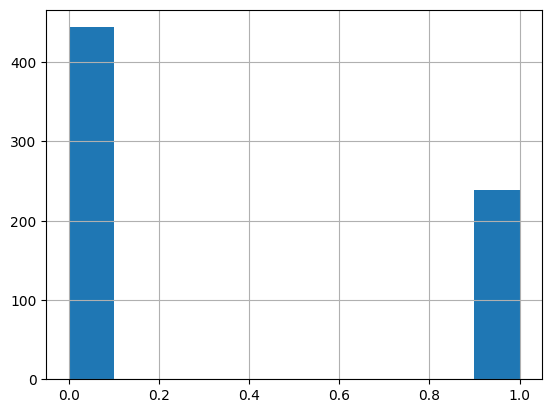

In [486]:
df_BC["Benign"].hist()

In [487]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

TARGET_COL = "Benign"
X = df_BC.drop(columns=[TARGET_COL])
y = df_BC[TARGET_COL]

print("Shape X:", X.shape, "| Shape y:", y.shape)
print("Répartition de la cible:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

logreg = LogisticRegression(
    solver="liblinear",
    max_iter=500,
    class_weight="balanced",
    random_state=42
)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print("\nAccuracy (test):", round(accuracy_score(y_test, y_pred), 4))
print("\nRapport de classification (test):")
print(classification_report(y_test, y_pred, digits=3))

coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values(ascending=False)
print("\nIntercept:", float(logreg.intercept_[0]))
print("\nCoefficients (beta) :")
display(coef.to_frame(name="beta"))


Shape X: (683, 9) | Shape y: (683,)
Répartition de la cible:
 Benign
0    444
1    239
Name: count, dtype: int64

Accuracy (test): 0.9649

Rapport de classification (test):
              precision    recall  f1-score   support

           0      0.991     0.955     0.972       111
           1      0.922     0.983     0.952        60

    accuracy                          0.965       171
   macro avg      0.956     0.969     0.962       171
weighted avg      0.967     0.965     0.965       171


Intercept: -5.769047483993969

Coefficients (beta) :


,beta
BareNuclei,0.492783
UniformityOfCellShape,0.312884
UniformityOfCellSize,0.290715
ClumpThickness,0.231480
Mitoses,0.194093
NormalNucleoli,0.150516
MarginalAdhesion,0.140185
BlandChromatin,0.004105
SingleEpithelialCellSize,-0.009519


In [488]:
import numpy as np
from itertools import combinations
from gurobipy import GRB

# --- 1) w et courses depuis la logreg ---
courses = list(X.columns)
beta = dict(zip(courses, logreg.coef_[0]))
b0 = float(logreg.intercept_[0])

# score "risque cancer" = -(beta·x + b0)  => w = -beta pour que delta aille dans le bon sens
w = {k: -beta[k] for k in courses}

def cancer_risk_score(row_dict):
    return -(sum(beta[k] * row_dict[k] for k in courses) + b0)

# --- 2) échantillon de 10 lignes ---
S = df_BC.sample(n=20, random_state=50).reset_index(drop=True)
X10 = S[courses]

def row_to_dict(i):
    return X10.iloc[i].to_dict()

# --- 3) solveurs (tes 4 fonctions) ---
langs = {
    "1-1": lambda a, b: solve_explanation_11_xy(a, b, w, courses, silent=True),
    "1-m": lambda a, b: solve_explanation_1m_xy(a, b, w, courses, silent=True),
    "m-1": lambda a, b: solve_explanation_m1_xy(a, b, w, courses, silent=True),
    "union": lambda a, b: solve_explanation_mixed_xy(a, b, w, courses, silent=True),
}

# --- 4) comptage global ---
tot = 0
explained = {L: 0 for L in langs}

for i, j in combinations(range(20), 2):
    xi, xj = row_to_dict(i), row_to_dict(j)

    # orienter : a ≻ b = a plus à risque de cancer
    if cancer_risk_score(xi) >= cancer_risk_score(xj):
        a, b = xi, xj
    else:
        a, b = xj, xi

    tot += 1

    for L, solver in langs.items():
        status, *_ = solver(a, b)
        if status == GRB.OPTIMAL:
            explained[L] += 1

# --- 5) taux global + ranking ---
rates = {L: explained[L] / tot for L in langs}
print(f"Total comparaisons = {tot}")
for L in ["1-1", "1-m", "m-1", "union"]:
    print(f"{L:>5} : {explained[L]}/{tot} = {rates[L]:.3f}")

ranking = sorted(rates.keys(), key=lambda L: rates[L], reverse=True)
print("\nRanking (taux d'explication global) :", ranking)


Total comparaisons = 190
  1-1 : 156/190 = 0.821
  1-m : 165/190 = 0.868
  m-1 : 160/190 = 0.842
union : 169/190 = 0.889

Ranking (taux d'explication global) : ['union', '1-m', 'm-1', '1-1']


## Dataset RATP

In [489]:
df_RATP=pd.read_csv("RATP_cleaned.csv")
df_RATP.head()

,Metro station,peak-entering-passengers/h,peak-passing-passengers/h,off-peak-entering-passengers/h,off-peak-passing-passengers/h,"strategic priority [0,10]","Station degradation level ([0,20] scale)","connectivity index [0,100]"
0,Odéon (Ligne 4),85000.0,8100.0,35500.0,3450.0,75.0,16.2,88.0
1,Place d'Italie (Lign 6),81000.0,8100.0,37500.0,3150.0,67.0,17.6,95.0
2,Jussieu (Ligne 7),74000.0,8900.0,37000.0,4050.0,68.0,16.8,79.0
3,Nation (Ligne 9),74000.0,7100.0,42000.0,4550.0,77.0,15.2,73.0
4,La Motte Picquet-Grenelle (Ligne 10),72000.0,7500.0,33000.0,4250.0,88.0,13.2,93.0


In [490]:
poids= df_RATP[df_RATP["Metro station"] == "weights"]
df_RATP = df_RATP[df_RATP["Metro station"] != "weights"].copy()


In [491]:
poids

,Metro station,peak-entering-passengers/h,peak-passing-passengers/h,off-peak-entering-passengers/h,off-peak-passing-passengers/h,"strategic priority [0,10]","Station degradation level ([0,20] scale)","connectivity index [0,100]"
10,weights,0.021498,0.188111,0.037622,0.322477,16.123831,67.182629,16.123831


In [492]:
import pandas as pd
from itertools import combinations
from gurobipy import Model, GRB, quicksum



def k_best_rankings_with_pool(df_RATP_clean, poids, TOPN=None, K=5, pool_solutions=50):
    # 1) features + weights
    courses = [c for c in df_RATP_clean.columns if c != "Metro station"]
    w_row = poids.iloc[0]
    w = {k: float(w_row[k]) for k in courses}

    # 2) scores dict
    scores = {
        row["Metro station"]: {k: float(row[k]) for k in courses}
        for _, row in df_RATP_clean.iterrows()
    }

    # 3) score pondéré (sert à orienter les préférences + tie-break)
    def weighted_sum(x):
        return sum(w[k] * x[k] for k in courses)

    names_all = list(scores.keys())
    names_all.sort(key=lambda n: weighted_sum(scores[n]), reverse=True)
    if TOPN is None:
        names = names_all
    else:
        names = names_all[:min(TOPN, len(names_all))]

    # 4) tes 4 langages (OR)
    solvers = [
        lambda a, b: solve_explanation_11_xy(a, b, w, courses, silent=True),
        lambda a, b: solve_explanation_1m_xy(a, b, w, courses, silent=True),
        lambda a, b: solve_explanation_m1_xy(a, b, w, courses, silent=True),
        lambda a, b: solve_explanation_mixed_xy(a, b, w, courses, silent=True),
    ]

    def explainable(a, b):
        for solve in solvers:
            status, *_ = solve(a, b)
            if status == GRB.OPTIMAL:
                return True
        return False

    # 5) préférences pref[i,j] ∈ {0,1}
    pref = {(i, j): 0 for i in names for j in names if i != j}

    for i, j in combinations(names, 2):
        xi, xj = scores[i], scores[j]
        si, sj = weighted_sum(xi), weighted_sum(xj)

        if si >= sj:
            better, worse = i, j
            a, b = xi, xj
        else:
            better, worse = j, i
            a, b = xj, xi

        if explainable(a, b):
            pref[(better, worse)] = 1

    # 6) MILP de ranking : x[i,j]=1 si i est avant j
    m = Model("ranking_pool")
    m.params.OutputFlag = 0

    x = m.addVars(names, names, vtype=GRB.BINARY, name="x")

    for i in names:
        m.addConstr(x[i, i] == 0)

    for i, j in combinations(names, 2):
        m.addConstr(x[i, j] + x[j, i] == 1)

    # transitivité (pas de cycles de longueur 3)
    for i in names:
        for j in names:
            if j == i:
                continue
            for k in names:
                if k == i or k == j:
                    continue
                m.addConstr(x[i, j] + x[j, k] + x[k, i] <= 2)

    # objectif: max nb de préférences satisfaites
    m.setObjective(quicksum(pref[(i, j)] * x[i, j] for (i, j) in pref), GRB.MAXIMIZE)

    # 7) solution pool
    m.params.PoolSearchMode = 2
    m.params.PoolSolutions = pool_solutions
    m.params.PoolGap = 0
    m.optimize()

    if m.Status != GRB.OPTIMAL or m.SolCount == 0:
        return [], m

    # 8) extraction K classements depuis le même pool
    def extract_order_from_solution(sol_idx: int):
        m.params.SolutionNumber = sol_idx

        wins = {}
        for i in names:
            wins[i] = sum(1 for j in names if j != i and x[i, j].Xn > 0.5)

        # ordre déterministe : wins desc, puis score pondéré desc, puis nom
        order = sorted(
            names,
            key=lambda n: (wins[n], weighted_sum(scores[n]), n),
            reverse=True
        )
        return order

    sol_to_read = min(K, m.SolCount)
    rankings = [extract_order_from_solution(s) for s in range(sol_to_read)]
    return rankings, m


# -------------------
# USAGE : résoudre UNE fois, puis afficher top3 et top5
# -------------------
rankings, model = k_best_rankings_with_pool(df_clean, poids, TOPN=None, K=5, pool_solutions=50)

rank3 = rankings[:3]
rank5 = rankings[:5]

print("Top 3 classements :")
for idx, r in enumerate(rank3, 1):
    print(f"#{idx} :", r)

print("\nTop 5 classements :")
for idx, r in enumerate(rank5, 1):
    print(f"#{idx} :", r)


Top 3 classements :
#1 : ['Odéon (Ligne 4)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Jussieu (Ligne 7)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne 9)', 'Reuilly-Diderot (Ligne 1)', 'Daumenil (Ligne 6)', 'Vaugirard (Ligne 12)']
#2 : ['Jussieu (Ligne 7)', 'Odéon (Ligne 4)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne 9)', 'Reuilly-Diderot (Ligne 1)', 'Daumenil (Ligne 6)', 'Vaugirard (Ligne 12)']
#3 : ['Odéon (Ligne 4)', 'Jussieu (Ligne 7)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne 9)', 'Reuilly-Diderot (Ligne 1)', 'Daumenil (Ligne 6)', 'Vaugirard (Ligne 12)']

Top 5 classements :
#1 : ['Odéon (Ligne 4)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Jussieu (Ligne 7)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne

## Dataset 27crit